# Getting Started

## First STLDriver object

In [1]:
import stlrom as stl
d = stl.STLDriver()
d.parse_string('signal x,y')
print(d)

# STLDriver object defined as
signal x, y

# With formulas

# Data:
No data yet.


## Adding signal data

In [2]:
d.add_sample([0, -0.4, 0.6]) # time, x, y
d.add_sample([0.5, 0.7, 0.1])
d.add_sample([1.1, -0.1, 0.7])
print(d)

# STLDriver object defined as
signal x, y

# With formulas

# Data:

# Signal x:
3 samples from t0=0 to t_end=1.1

# Signal y:
3 samples from t0=0 to t_end=1.1



## First Plots

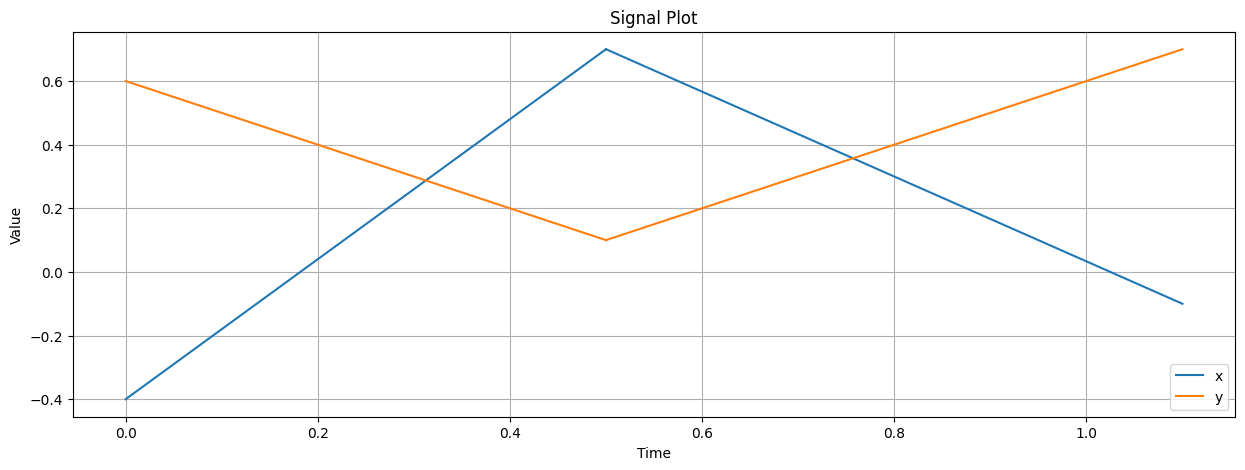

In [3]:
ax = d.plot_signals(['x', 'y'])

## First Predicates

In [4]:
d.parse_string("""
mu_x    := x[t]>0
mu_y    := y[t]>.5
mu_comp := x[t]<y[t]
""")
print(d)

# STLDriver object defined as
signal x, y

# With formulas
mu_comp:= x[t] < y[t]
mu_x:= x[t] > 0
mu_y:= y[t] > 0.5

# Data:

# Signal x:
3 samples from t0=0 to t_end=1.1

# Signal y:
3 samples from t0=0 to t_end=1.1



## Satisfaction Evaluation

### Boolean Satisfaction

In [5]:
d.set_semantics('BOOLEAN')
sat_mu = d.get_rob_signal('mu_x',0,1.1)
print(sat_mu)

begin_time: 0  end_time: 1.1
time:          0  value:          0  derivative:          0
time:     0.1818  value:          1  derivative:          0
time:      1.025  value:          0  derivative:          0



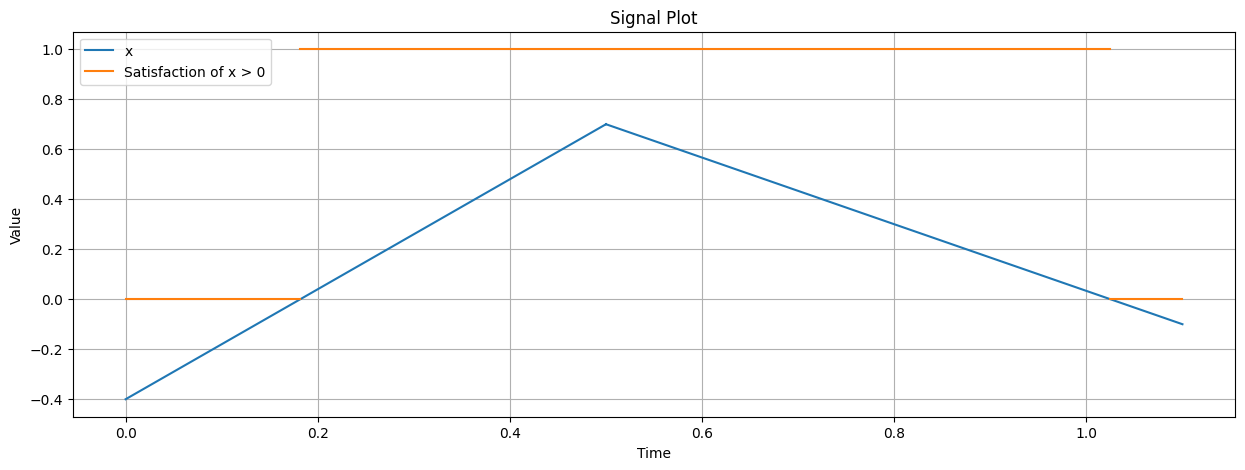

In [6]:
ax = d.plot_signal('x')  # plots signal x, returns axis
ax = sat_mu.plot(label='Satisfaction of x > 0', ax=ax)


### Robust Satisfaction

In [7]:
sat_mu_y = d.get_rob_signal('mu_y',0,1.1)
print(sat_mu_y)

begin_time: 0  end_time: 1.1
time:          0  value:          1  derivative:          0
time:        0.1  value:          0  derivative:          0
time:        0.9  value:          1  derivative:          0



In [8]:
d.set_semantics('SPACE')
rob_mu_y = d.get_rob_signal('mu_y',0,1.1)
print(rob_mu_y)

begin_time: 0  end_time: 1.1
time:          0  value:        0.1  derivative:         -1
time:        0.1  value:     -1e-10  derivative:          0
time:        0.1  value:     -1e-10  derivative:         -1
time:        0.5  value:       -0.4  derivative:          1
time:        0.9  value:     -1e-10  derivative:          1
time:        0.9  value:      1e-10  derivative:          1
time:        1.1  value:        0.2  derivative:          0



<Axes: title={'center': 'Signal Plot'}, xlabel='Time', ylabel='Value'>

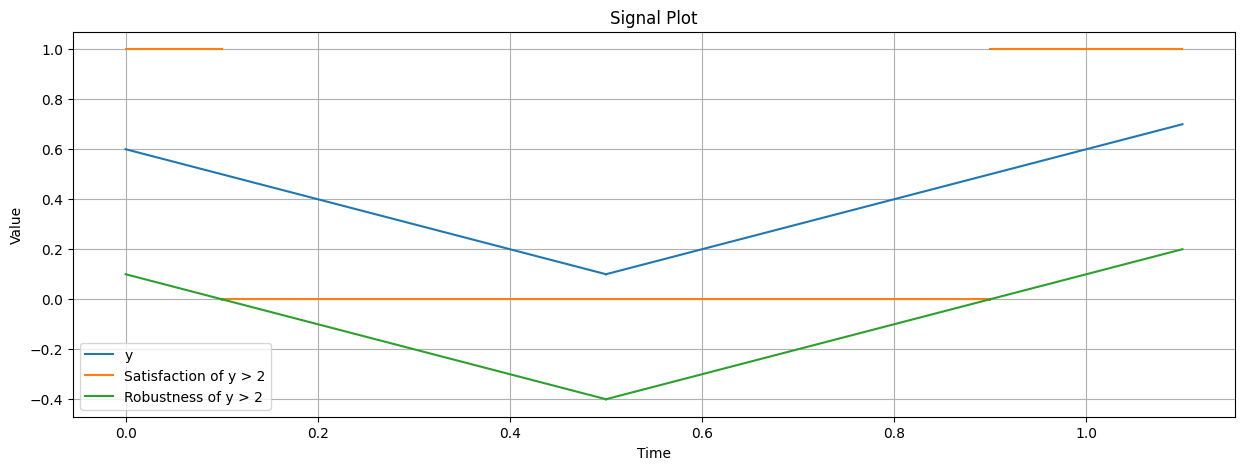

In [9]:
ax = d.plot_signal('y')  # plots signal x, returns axis
sat_mu_y.plot(label='Satisfaction of y > 2', ax=ax)
rob_mu_y.plot(label='Robustness of y > 2', ax=ax)


step plot


<Axes: title={'center': 'Signal Plot'}, xlabel='Time', ylabel='Value'>

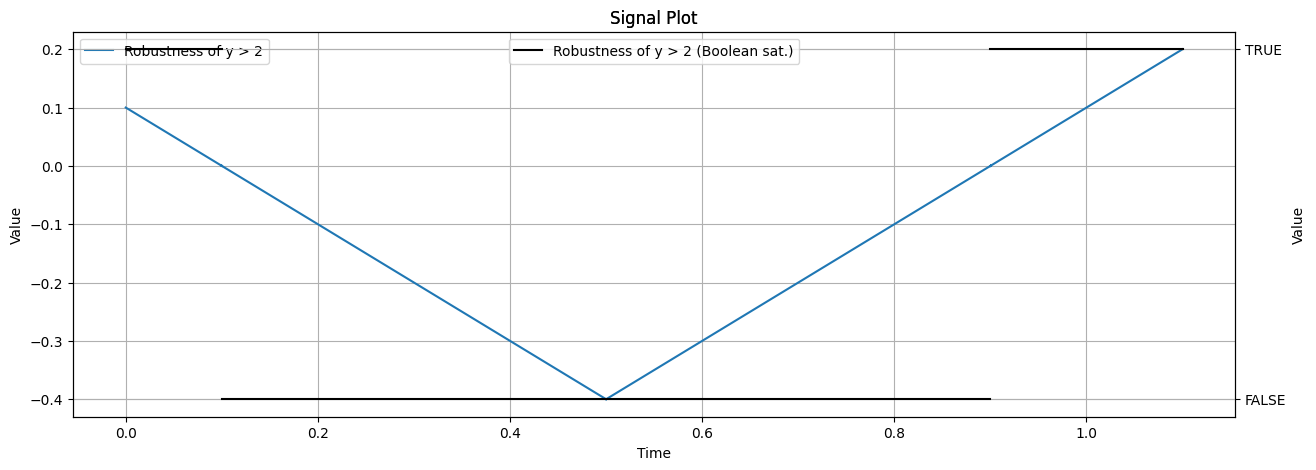

In [10]:
rob_mu_y.plot(label='Robustness of y > 2', plot_sat=True)


# Signal Generation

### Piecewise Constant Signal 

In [ ]:
from stlrom import PWCSignalGen

pwc_gen = PWCSignalGen(times=[0, 1., 2., 2.5, 3.],
                       values=[0., 1., -0.5, 0.8, 0.5])
pwc_signal = pwc_gen.get_signal(t0=0, tf=3)
pwc_signal.plot(label='PWC signal');

### Piecewise Linear Signals

In [ ]:
from stlrom import PWLSignalGen

pwl_gen = PWLSignalGen(times=[0, 1., 2., 2.5, 3.],
                       values=[0., 1., -0.5, 0.8, 0.5])
pwl_signal = pwl_gen.get_signal(t0=0, tf=3)
pwl_signal.plot(label='PWL signal');

### Oscillation Signals

In [ ]:
from stlrom import OscillSignalGen

osc_gen = OscillSignalGen(period=2, amplitude=0.25, base=0, damp=-0.5)
osc_signal= osc_gen.get_signal(t0=0, tf=10, dt=0.02)
osc_signal.plot(label='Oscillating signal');


# Robustness of Equality

In [ ]:
d2 = stl.STLDriver()
d2.parse_string("""
    signal x
    mu_eq := x[t] == 0
    """)

d2.set_signals([osc_signal])
print(d2)

In [ ]:
stl.Signal.set_Eps(0.01)

rob_eq = d2.get_rob_signal('mu_eq', 0, 10)

ax = osc_signal.plot(label='Oscillating signal');
ax.plot([0, osc_signal.end_time], [stl.Signal.get_Eps(), stl.Signal.get_Eps()], linestyle='--', color='black', label="± $\\varepsilon$")
ax.plot([0, osc_signal.end_time], [-stl.Signal.get_Eps(), -stl.Signal.get_Eps()], linestyle='--', color='black')
ax = rob_eq.plot(label='Robustness of mu_eq for oscillating signal', ax=ax);



In [ ]:
stl.Signal.set_Eps(1e-12)

# Temperature Example

## Generating Signal

In [ ]:
import numpy as np
times = np.linspace(0, 12, 100)
values = 18 + 9 * np.sin(times) + 3 * np.sin(3 * times)
temp_signal = PWLSignalGen(times = times, values = values).get_signal(tf=12)

ax = temp_signal.plot(label='Temperature signal');
ax.plot([0, temp_signal.end_time], [25, 25], linestyle='--', color='black', label="Threshold temperature");
ax.legend();


## Parsing Formulas

In [ ]:
d3 = stl.STLDriver()
d3.parse_string("""signal temp                
    param Tmax = 25, tau=2
    mu_temp := temp[t] < Tmax

    # Temperature should always be below Tmax
    phi_ev := ev[0, tau] (mu_temp)

    # If temperature is above Tmax, it should eventually be below Tmax within 2 seconds
    phi := alw[0, 8 ] ((not mu_temp) => phi_ev)
    """)

d3.set_signals([temp_signal])

## Robustness of Top Formula

In [ ]:
d3.set_param('tau', 1);d3.set_param('Tmax', 20);
d3.set_semantics('BOOLEAN')
sat_phi_ev = d3.get_rob_signal('phi_ev', 0,6)
d3.set_semantics('SPACE')
r_phi_ev = d3.get_rob_signal('phi_ev', 0, 6)

ax = temp_signal.plot(label='Temperature signal');
r_phi_ev.plot(label='Robustness of phi_ev', ax=ax);

ax_bool = ax.twinx(); ax_bool.set_yticks([0, 1]); ax_bool.set_yticklabels(['False', 'True']);
sat_phi_ev.plot(label ='Satisfaction of phi_ev', ax=ax_bool, color='green');

## Robustness Map

In [ ]:
r_phi, _, _ = d3.get_online_rob_signal('phi', 0, 6)
rob_map = d3.get_online_robustness_map('phi')
stl.plot_rob_map_widget(rob_map)